In [2]:
import json
import numpy as np
import pandas as pd
from scipy import stats

In [29]:
datasets = {
    "fashion": {},
    "mnist": {},
    "kmnist": {}
}

for name, data in datasets.items():
    with open(f"./whole/tests/GA/{name}/results_AE.json", "r") as file:
        AE = json.load(file) # list of dictionaries
        data["AE"] = AE

    with open(f"./whole/tests/GA/{name}/results_noAE.json", "r") as file:
        noAE = json.load(file) # list of dictionaries
        data["noAE"] = noAE

In [ ]:
def fetch_dv(results:dict, what:str):
    """return either list if what="fit_in_time" or int if what="test_fit" """
    dv = results[what]
    return dv

[{'dataset': 'fashion', 'pop_size': 15, 'runs': 32, 'gens': 21, 'exp_condition': True, 'seed': 34, 'subset_fraction': 0.07, 'decay': True, 'm_r_min': 0.01, 'm_r_max': 0.3, 'm_strength': 0.2, 'm_mode': 'light'}, {'fit_in_time': [0.11169840395450592, 0.11876190453767776, 0.13049206137657166, 0.14450792968273163, 0.15380951762199402, 0.15895238518714905, 0.16304761171340942, 0.17099998891353607, 0.17493648827075958, 0.1777460277080536, 0.1827142834663391, 0.18365079164505005, 0.18555554747581482, 0.18615871667861938, 0.19173015654087067, 0.1995396912097931, 0.19960317015647888, 0.20112697780132294, 0.20739680528640747, 0.2209523767232895, 0.23236507177352905], 'test_fit': 0.21895238095238095}, {'fit_in_time': [0.12903174757957458, 0.13541269302368164, 0.1435396820306778, 0.14998413622379303, 0.15268254280090332, 0.15696826577186584, 0.16336508095264435, 0.16496826708316803, 0.1702222228050232, 0.17653967440128326, 0.18044444918632507, 0.18542858958244324, 0.1946825385093689, 0.20328572392

In [ ]:
summary = {
    "fashion": [], # gonna be list of two lists 
    "mnist": [],
    "kmnist": []
}

for name, results in datasets.items():
    AE = [fetch_dv(results["AE"][i], "test_fit") for i in range(len(results["AE"])) if i != 0]
    noAE = [fetch_dv(results["noAE"][i], "test_fit") for i in range(len(results["noAE"])) if i != 0]
    summary[name] = [AE, noAE]

In [37]:
for i in summary["kmnist"]:
    print(sum(i)/len(i))

0.16783928571428572
0.16861607142857143


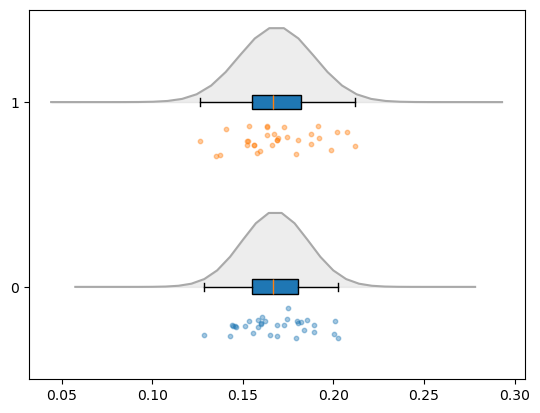

In [45]:
from whole.ga.rainclouds import rainclouds

AE = np.array(summary["kmnist"][0])
noAE = np.array(summary["kmnist"][1])
groups = [AE, noAE]

rainclouds(groups=groups, assume_normal=True)

In [21]:
stats.ttest_ind(fashion_AE, fashion_noAE, equal_var=False) # equal_var?????

TtestResult(statistic=np.float64(0.8474374469637624), pvalue=np.float64(0.40001181207596803), df=np.float64(61.982449396903114))